<a href="https://colab.research.google.com/github/raisa1521/Hands-on-Machine-Learning/blob/main/6%EC%9E%A5_%EA%B2%B0%EC%A0%95%ED%8A%B8%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **6장 결정 트리**

**결정 트리(Decision Tree)** : 분류와 회귀 작업, 다중 출력 작업까지 가능한 다목적 머신러닝 알고리즘

- 매우 복잡한 데이터셋도 학습할 수 있음
- 제한하지 않으면 훈련 데이터에 과대적합될 수 있음
- 랜덤 포레스트의 기본 구성 요소

## **6.1 결정 트리 학습과 시각화**

붓꽃 데이터셋에 DecisionTreeClassifier를 훈련해 결정 트리 만들기

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)

X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [3]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=["꽃잎 길이(cm)", "꽃잎 너비(cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

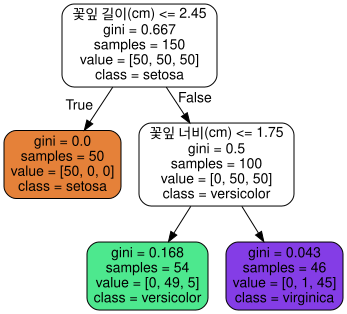

In [4]:
from graphviz import Source

Source.from_file("iris_tree.dot")

## **6.2 예측**

결정 트리는 루트 노드에서 시작하여 각 조건에 따라 왼쪽 또는 오른쪽 자식 노드로 이동하면서 예측

- 루트 노드: 깊이가 0인 맨 위의 노드
- 자식 노드 : 현재 노드 아래에 연결된 노드
- 리프 노드 : 자식 노드를 가지지 않는 노드
- 분할 노드 : 추가적인 조건 검사를 수행하는 노드

붓꽃 결정 트리의 첫 번째 조건은 꽃잎 길이가 2.45cm보다 짧은지 확인하는 것이다.

꽃잎 길이 2.45보다 작으면 -> 왼쪽 리프 노드로 이동, Iris-Setosa로 예측

꽃잎 길이 2.45보다 크면 -> 오른쪽 자식 노드로 이동, 꽃잎 너비가 1.75cm보다 작은지 다시 검사

꽃잎 너비 1.75보다 작으면 -> Iris-Versicolor
크면 -> Iris-Virginica

결정 트리의 장점 : 데이터 전처리가 거의 필요X  특성의 스케일을 맞추거나 평균을 원점에 맞추는 작업이 필요 X

###6-1 지니 불순도

$G_i=1-\sum_{k=1}^{n}p_{i,k}^2$

$G_i$ : i번째 노드의 지니 불순도


$p_{i,k}$ : i번째 노드의 훈련 샘플 중 클래스 k에 속한 샘플의 비율

## **6.3 클래스 확률 추정**

결정 트리는 샘플이 특정 클래스 k에 속할 확률도 추정 가능

1. 샘플이 도달하는 리프 노드를 찾음
2. 해당 리프 노드에서 클래스 k에 속하는 훈련 샘플의 비율을 반환

예시

꽃잎 길이가 5cm이고 너비가 1.5인 경우 도달하는 리프 노드에는 총 54개의 훈련 샘플

- Iris-Setosa : 0%
- Iris-Versicolor : 90.7%
- Iris-Virginica : 9.3%

가장 높은 확률을 가진 Iris-Versicolor 예측

In [5]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [6]:
tree_clf.predict([[5, 1.5]])

array([1])

=> 추정된 클래스 확률이 동일

## **6.5 계산 복잡도**

예측을 하려면 결정 트리의 루트 노드에서 리프 노드까지 탐색

일반적으로 결정 트리는 거의 균형을 이루므로 약 O(log_2(m))개의 노드를 거침.
각 노드는 하나의 특성값만 확인-> 예측에 필요한 전체 복잡도는 특성 수와 무관하게 O(log_2(m))

-> 큰 훈련 세트에서도 예측 속도가 매우 빠름

훈련 과정에서는 각 노드에서 훈련 샘플의 모든 특성을 비교

각 노드에서 모든 샘플의 모든 특성을 비교할 경우 훈련 복잡도는
O(n*mlog_2(m))
